In [2]:
# === System & OS Utilities ===
import os
import math
import pickle
import sys
import warnings
import random
warnings.filterwarnings("ignore")

# === Progress Bar ===
from tqdm import tqdm

# === TensorFlow & Keras ===
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adamax, AdamW
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.metrics import Precision, Recall, AUC
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers
from tensorflow.keras.layers import Layer
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (Conv2D, 
                                     Dense,
                                     Dropout,
                                     Flatten,
                                     GlobalAveragePooling2D,
                                     GlobalMaxPooling2D,
                                     MaxPooling2D,
                                     BatchNormalization,
                                     ReLU,
                                     Add)
from tensorflow.keras.layers import (
    Layer, Conv2D, Dense, Dropout,
    GlobalAveragePooling2D, GlobalMaxPooling2D,
    Reshape, Multiply, Add, Activation, Concatenate
)
import os, numpy as np, cv2
from skimage.feature import local_binary_pattern
from tensorflow.keras import layers, Model, initializers
from tensorflow.keras.layers import Layer
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# === Data Handling ===
import numpy as np
import pandas as pd
import cv2

# === Visualization ===
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# === Scikit-learn ===
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report, confusion_matrix
)

In [2]:
print("Python version:", sys.version)
print("TensorFlow version:", tf.__version__)
print("Keras version:", tf.keras.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("OpenCV version:", cv2.__version__)
print("Matplotlib version:", matplotlib.__version__)
print("Seaborn version:", sns.__version__)
print("Scikit-learn version:", sklearn.__version__)

Python version: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
TensorFlow version: 2.18.0
Keras version: 3.8.0
NumPy version: 1.26.4
Pandas version: 2.2.3
OpenCV version: 4.12.0
Matplotlib version: 3.7.2
Seaborn version: 0.12.2
Scikit-learn version: 1.2.2


In [3]:
#python version 3.11.11
#!python -m pip install tensorflow==2.18.0 keras==3.5.0 numpy==1.26.4 pandas==2.2.3 opencv-python==4.6.0.66 matplotlib==3.7.5 seaborn==0.12.2 scikit-learn==1.2.2

In [4]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPUs detected: {len(gpus)}")
    except RuntimeError as e:
        print(f"Error setting GPU memory growth: {e}")
else:
    print("No GPUs detected.")

GPUs detected: 1


In [3]:
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
EPOCH = 50
img_shape=(*IMG_SIZE,3)
dataset_path = r"/kaggle/input/skin-cancer-merged-preprocess-binary-dataset/SKIN IMAGE MERGED"
dataset_path = r"C:\Users\Faysal Ahmmed\Desktop\New folder\Dataset Preprocessed\SKIN IMAGE MERGED"
labels = ['Benign', 'Malignant']
print("Class Names:", labels)

Class Names: ['Benign', 'Malignant']


In [4]:
def data_frame(path):
    class_paths = []
    classes = []

    for label in os.listdir(path):
        class_dir = os.path.join(path, label)
        if os.path.isdir(class_dir):  
            for image in os.listdir(class_dir):
                class_paths.append(os.path.join(class_dir, image))
                classes.append(label)

    df = pd.DataFrame({'Class Path': class_paths, 'Class': classes})
    return df

In [5]:
main_frame = data_frame(dataset_path)

# First split: 80% train, 20% temp
train_dataframe, temp_dataframe = train_test_split(
    main_frame,
    test_size=0.20,              
    random_state=42,
    stratify=main_frame['Class']
)

validation_dataframe, test_dataframe = train_test_split(
    temp_dataframe,
    test_size=0.5,            
    random_state=42,
    stratify=temp_dataframe['Class']
)

#validation_dataframe = test_dataframe = temp_dataframe

train_counts = train_dataframe['Class'].value_counts()
val_counts = validation_dataframe['Class'].value_counts()
test_counts = test_dataframe['Class'].value_counts()

count_table = pd.DataFrame({
    "Train": train_counts,
    "Validation": val_counts,
    "Test": test_counts
}).fillna(0).astype(int)

count_table["Total"] = count_table.sum(axis=1)
grand_total = pd.DataFrame({
    "Train": [count_table["Train"].sum()],
    "Validation": [count_table["Validation"].sum()],
    "Test": [count_table["Test"].sum()],
    "Total": [count_table["Total"].sum()]
}, index=["Total"])
count_table = pd.concat([count_table, grand_total])

print(count_table)

BATCH_SIZE = min(BATCH_SIZE, len(validation_dataframe))
print(f"Batch Size = {BATCH_SIZE}")

           Train  Validation  Test  Total
Benign     13098        1637  1638  16373
Malignant  10885        1361  1360  13606
Total      23983        2998  2998  29979
Batch Size = 32


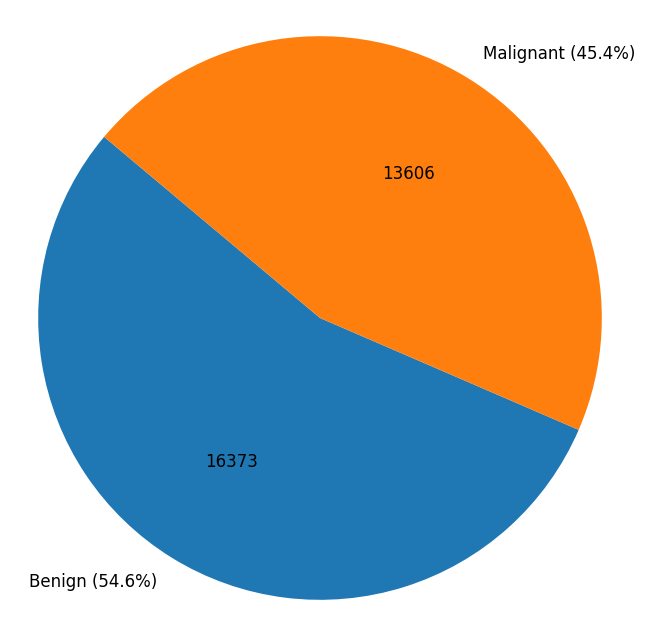

In [8]:
# Combine and sum the counts
total_counts = train_counts.add(val_counts, fill_value=0)
total_counts = total_counts.add(test_counts, fill_value=0)
total_counts = total_counts.sort_index()

# Prepare labels with percentages
total = total_counts.sum()
labels_with_percent = [f"{label} ({(count/total)*100:.1f}%)" for label, count in zip(total_counts.index, total_counts.values)]

# Define custom autopct function to show raw count
def make_autopct(values):
    def autopct(pct):
        total = sum(values)
        count = int(round(pct * total / 100.0))
        return f"{count}"
    return autopct

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(total_counts.values, labels=labels_with_percent, autopct=make_autopct(total_counts.values), startangle=140, textprops={'fontsize': 12})
plt.axis('equal')
plt.show()

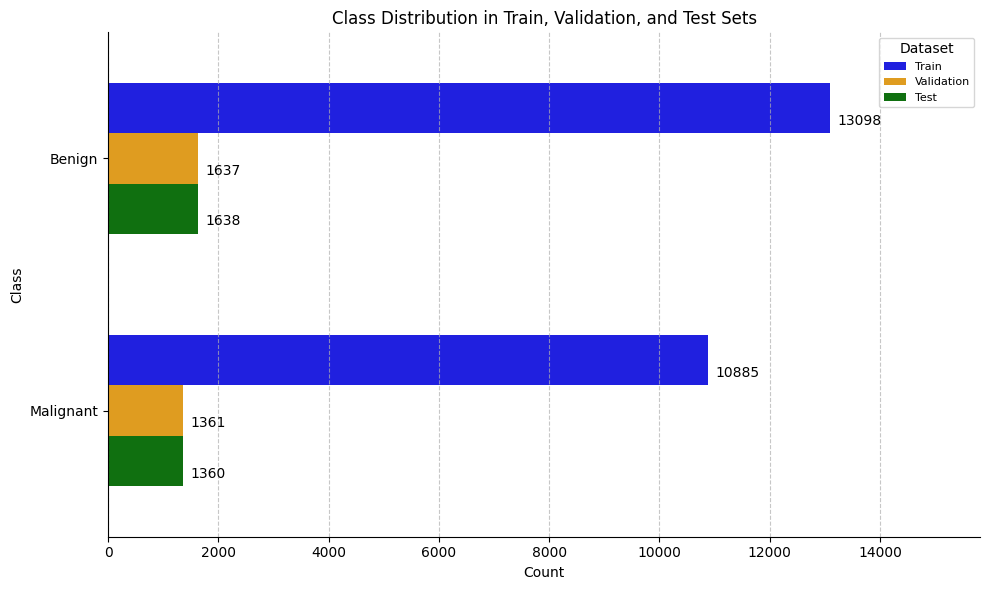

In [9]:
# Count occurrences of each class in train, validation, and test datasets
train_counts = train_dataframe['Class'].value_counts().sort_index()
val_counts = validation_dataframe['Class'].value_counts().sort_index()
test_counts = test_dataframe['Class'].value_counts().sort_index()

# Combine into a DataFrame with the index kept as a column
data_counts = pd.DataFrame({
    'Class': train_counts.index,
    'Train': train_counts.values,
    'Validation': val_counts.values,
    'Test': test_counts.values
}).melt(id_vars='Class', var_name='Dataset', value_name='Count')

# Plot the horizontal bar chart
plt.figure(figsize=(10, 6))
ax = sns.barplot(y='Class', x='Count', hue='Dataset', data=data_counts, 
                 palette=['blue', 'orange', 'green'], orient='h', width=0.6)

# Add count labels to the right of the bars with slight downward offset
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}', 
                (p.get_width(), p.get_y() + p.get_height() / 2.0 + 0.05),  # pushed slightly down
                ha='left', va='center', 
                fontsize=10, color='black', 
                xytext=(5, 0), textcoords='offset points')

# Remove borders (spines)
sns.despine(top=True, right=True, left=False, bottom=False)

# Dynamically set the x-axis limits with some extra space on the right
left, right = ax.get_xlim()  # Get current x-limits

# Set the new right limit with a 15% increase
right += (right - left) * 0.15  # Increase right by 15%

# Apply the new limits to the x-axis
ax.set_xlim(left, right)

# Add labels and title
plt.ylabel("Class")
plt.xlabel("Count")
plt.title("Class Distribution in Train, Validation, and Test Sets")

# Move the legend
plt.legend(title="Dataset", loc='upper right', fontsize=8)

# Add grid only along x-axis
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Tidy layout
plt.tight_layout()
plt.show()

In [6]:
def preprocess_image(image):

    image = image.astype(np.float32)

    min_val = image.min()
    max_val = image.max()

    # avoid division by zero
    if max_val - min_val < 1e-6:
        return np.zeros_like(image, dtype=np.float32)

    # min-max scale to [0, 1]
    image = (image - min_val) / (max_val - min_val)
    
    return image

In [7]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_image, 
    # ----- geometric augmentations -----
    rotation_range=180,         # lesions can be in any orientation
    zoom_range=0.15,            # ±15% zoom
    width_shift_range=0.05,     # max 5% shift (safe)
    height_shift_range=0.05,    # max 5% shift
    horizontal_flip=True,       # widely used in ISIC competitions
    vertical_flip=True,         # acceptable in dermoscopy

    # ----- photometric augmentations  -----
    brightness_range=[0.8, 1.2],  # control illumination variation
    channel_shift_range=15,        # mild color shift 
    fill_mode='nearest',
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_image)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_image)


train_data = train_datagen.flow_from_dataframe(train_dataframe, x_col='Class Path',
                                  y_col='Class', batch_size=BATCH_SIZE,
                                  target_size=IMG_SIZE, class_mode='binary', seed=42)

validation_data = val_datagen.flow_from_dataframe(validation_dataframe, x_col='Class Path',
                                     y_col='Class', batch_size=BATCH_SIZE,
                                     target_size=IMG_SIZE, class_mode='binary', seed=42)

test_data = test_datagen.flow_from_dataframe(test_dataframe, x_col='Class Path',
                                  y_col='Class', batch_size=BATCH_SIZE,
                                  target_size=IMG_SIZE, class_mode='binary', shuffle=False, seed=42)

Found 23983 validated image filenames belonging to 2 classes.
Found 2998 validated image filenames belonging to 2 classes.
Found 2998 validated image filenames belonging to 2 classes.


In [8]:
class RestoreBestValidationModel(Callback):
    """
    Custom Keras Callback to restore model weights from the best epoch based on validation accuracy.
    - Tracks the best validation accuracy during training.
    - Restores the model weights from the epoch with the best validation accuracy when training finishes.
    """
    
    def __init__(self):
        super(RestoreBestValidationModel, self).__init__()
        # Initialize best validation accuracy, epoch, and weights to track the best model
        self.best_val_acc = -1
        self.best_epoch = -1
        self.best_weights = None

    def on_epoch_end(self, epoch, logs=None):
        """
        Callback function executed at the end of each epoch.
        - Compares the current validation accuracy with the best validation accuracy.
        - If the current validation accuracy is higher or tied but at a later epoch, updates the best model weights.
        """
        # Get validation accuracy from logs
        val_acc = logs.get('val_accuracy')
        
        if val_acc is not None:
            # Update the best validation accuracy and weights if the current one is better or at a later epoch
            if val_acc > self.best_val_acc or (val_acc == self.best_val_acc and epoch > self.best_epoch):
                self.best_val_acc = val_acc
                self.best_epoch = epoch
                self.best_weights = self.model.get_weights()  # Store the model's weights
                print(f"\nModel weights updated at epoch {epoch + 1} with val_accuracy: {val_acc:.4f}")

    def on_train_end(self, logs=None):
        """
        Callback function executed at the end of training.
        - Restores the model weights from the epoch with the best validation accuracy.
        """
        # If we found a better model during training, restore the best weights
        if self.best_weights is not None:
            print(f"Restoring model weights from best epoch {self.best_epoch + 1} with val_accuracy: {self.best_val_acc:.4f}")
            self.model.set_weights(self.best_weights)  # Set the weights back to the best model's weights

# Instantiate the callback
restore_best = RestoreBestValidationModel()


In [13]:
"""
Stronger Novel compact skin-lesion classifier (Keras)
- GhostModule + GhostBottleneck (GhostNet idea) with larger expansion
- Mamba-inspired token-mixing block (vision-adaptation) (Layer)
- CoordAttention (spatial coordinate attention)
- Squeeze-and-Excitation micro module added
- Deeper / wider stages to reach ~4-5M params
- Serializable custom layers (register_keras_serializable)
"""

import math
import tensorflow as tf
from tensorflow.keras import layers, Model, Input, backend as K

# ---------------------------
# Squeeze-and-Excitation (tiny, lightweight)
# ---------------------------
@tf.keras.utils.register_keras_serializable(package="Custom", name="SEBlock")
class SEBlock(layers.Layer):
    def __init__(self, reduction=4, **kwargs):
        super().__init__(**kwargs)
        self.reduction = reduction

    def build(self, input_shape):
        C = int(input_shape[-1])
        self.global_pool = layers.GlobalAveragePooling2D()
        self.fc1 = layers.Dense(max(8, C // self.reduction), activation='relu', use_bias=True)
        self.fc2 = layers.Dense(C, activation='sigmoid', use_bias=True)
        super().build(input_shape)

    def call(self, x):
        s = self.global_pool(x)            # (B, C)
        s = self.fc1(s)
        s = self.fc2(s)                    # (B, C)
        s = tf.reshape(s, (-1, 1, 1, int(x.shape[-1])))
        return x * s

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"reduction": self.reduction})
        return cfg

# ---------------------------
# CoordAttention (Layer, serializable)
# ---------------------------
@tf.keras.utils.register_keras_serializable(package="Custom", name="CoordAttention")
class CoordAttention(layers.Layer):
    def __init__(self, reduction=32, **kwargs):
        super().__init__(**kwargs)
        self.reduction = reduction

    def build(self, input_shape):
        # input_shape: (B, H, W, C)
        _, H, W, C = input_shape
        self.C = int(C)
        self.pool_conv_channels = max(8, self.C // self.reduction)
        self.conv1 = layers.Conv2D(self.pool_conv_channels, kernel_size=1, use_bias=False)
        self.act = layers.Activation('gelu')
        self.conv_h = layers.Conv2D(self.C, kernel_size=1, use_bias=False)
        self.conv_w = layers.Conv2D(self.C, kernel_size=1, use_bias=False)
        super().build(input_shape)

    def call(self, x):
        # x: (B,H,W,C)
        fh = K.mean(x, axis=2, keepdims=True)         # (B,H,1,C)
        fw = K.mean(x, axis=1, keepdims=True)         # (B,1,W,C)
        fw_t = tf.transpose(fw, [0,2,1,3])            # (B,W,1,C)
        cat = tf.concat([fh, fw_t], axis=1)           # (B,H+W,1,C)
        cat = self.conv1(cat)
        cat = self.act(cat)
        H_dyn = tf.shape(fh)[1]                       # dynamic height
        fh_hat = cat[:, :H_dyn, :, :]
        fw_hat = cat[:, H_dyn:, :, :]
        fw_hat = tf.transpose(fw_hat, [0,2,1,3])
        ah = tf.sigmoid(self.conv_h(fh_hat))
        aw = tf.sigmoid(self.conv_w(fw_hat))
        out = x * ah * aw
        return out

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"reduction": self.reduction})
        return cfg

# ---------------------------
# Ghost Module (GhostConv)
# ---------------------------
def GhostModule(x, out_channels, ratio=2, dw_kernel=3, name=None):
    """
    Basic Ghost module:
      - primary: pointwise conv generating intrinsic features
      - cheap: depthwise conv on primary to generate 'ghost' features
      - concat and project to out_channels
    """
    init_channels = math.ceil(out_channels / ratio)   # intrinsic channels
    primary = layers.Conv2D(init_channels, kernel_size=1, padding='same', use_bias=False)(x)
    primary = layers.BatchNormalization()(primary)
    primary = layers.Activation('gelu')(primary)

    cheap = layers.DepthwiseConv2D(kernel_size=dw_kernel, padding='same', depth_multiplier=1, use_bias=False)(primary)
    cheap = layers.BatchNormalization()(cheap)
    cheap = layers.Activation('gelu')(cheap)

    concat = layers.Concatenate(axis=-1)([primary, cheap])
    out = layers.Conv2D(out_channels, kernel_size=1, padding='same', use_bias=False)(concat)
    out = layers.BatchNormalization()(out)
    return out

# ---------------------------
# Ghost Bottleneck (like GhostNet) — using K.int_shape to get channel dim
# ---------------------------
def GhostBottleneck(inputs, out_channels, stride=1, expansion=2.0, name=None):
    in_ch = int(K.int_shape(inputs)[-1])
    hidden_channels = int(round(in_ch * expansion))

    # 1) GhostModule expand
    x = GhostModule(inputs, hidden_channels)
    # 2) depthwise conv (if stride>1)
    if stride > 1:
        x = layers.DepthwiseConv2D(kernel_size=3, strides=stride, padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)

    # 3) GhostModule project
    x = GhostModule(x, out_channels)

    # shortcut
    if stride == 1 and in_ch == out_channels:
        out = layers.Add()([inputs, x])
    else:
        # downsample shortcut / project
        shortcut = inputs
        if stride > 1:
            shortcut = layers.DepthwiseConv2D(kernel_size=3, strides=stride, padding='same', use_bias=False)(shortcut)
            shortcut = layers.BatchNormalization()(shortcut)
            shortcut = layers.Conv2D(out_channels, kernel_size=1, padding='same', use_bias=False)(shortcut)
            shortcut = layers.BatchNormalization()(shortcut)
        else:
            shortcut = layers.Conv2D(out_channels, kernel_size=1, padding='same', use_bias=False)(shortcut)
            shortcut = layers.BatchNormalization()(shortcut)
        out = layers.Add()([x, shortcut])
    return out

# ---------------------------
# Mamba-inspired Vision Block (Layer version, serializable)
# ---------------------------
@tf.keras.utils.register_keras_serializable(package="Custom", name="MambaInspiredBlock")
class MambaInspiredBlock(layers.Layer):
    """
    Vision-adapted Mamba-inspired block as a Keras Layer (token-mixing)
    """
    def __init__(self, expansion=1.5, kernel=7, **kwargs):
        super().__init__(**kwargs)
        self.expansion = expansion
        self.kernel = kernel
        self.ln = layers.LayerNormalization(epsilon=1e-6)
        self.expand_dense = None
        self.conv1d = None
        self.gate_conv1d = None
        self.proj_dense = None
        self.act = layers.Activation('gelu')
        self.sigmoid = layers.Activation('sigmoid')
        self.multiply = layers.Multiply()
        self.add = layers.Add()

    def build(self, input_shape):
        C = int(input_shape[-1])
        hidden_dim = int(max(1, C * self.expansion))
        self.expand_dense = layers.Dense(hidden_dim, use_bias=False)
        self.conv1d = layers.Conv1D(filters=hidden_dim, kernel_size=self.kernel, padding='same', use_bias=False)
        self.gate_conv1d = layers.Conv1D(filters=hidden_dim, kernel_size=1, padding='same', use_bias=False)
        self.proj_dense = layers.Dense(C, use_bias=False)
        super().build(input_shape)

    def call(self, x):
        x_ln = self.ln(x)
        shape = tf.shape(x_ln)
        B = shape[0]; H = shape[1]; W = shape[2]
        C_static = int(x_ln.shape[-1])
        N = H * W
        tokens = tf.reshape(x_ln, (B, N, C_static))
        hidden = self.expand_dense(tokens)
        hidden = self.act(hidden)
        mixed = self.conv1d(hidden)
        mixed = self.act(mixed)
        gate = self.gate_conv1d(tokens)
        gate = self.sigmoid(gate)
        gated = self.multiply([mixed, gate])
        proj = self.proj_dense(gated)
        proj = tf.reshape(proj, (B, H, W, C_static))
        out = self.add([x, proj])
        return out

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"expansion": self.expansion, "kernel": self.kernel})
        return cfg

# ---------------------------
# Micro block that mixes types (with SE)
# ---------------------------
def hybrid_block(x, out_ch, use_coord=False, use_ghost=True, use_mamba=False, se_reduction=4):
    """
    Hybrid residual block:
    - GhostBottleneck (or DW+PW)
    - optional CoordAttention
    - optional Mamba token-mixing
    - small SE module
    """
    shortcut = x
    if use_ghost:
        y = GhostBottleneck(x, out_ch, stride=1, expansion=2.0)
    else:
        y = layers.DepthwiseConv2D(kernel_size=3, padding='same', use_bias=False)(x)
        y = layers.BatchNormalization()(y)
        y = layers.Conv2D(out_ch, kernel_size=1, padding='same', use_bias=False)(y)
        y = layers.BatchNormalization()(y)
        y = layers.Activation('gelu')(y)

    if use_coord:
        y = CoordAttention(reduction=8)(y)

    if use_mamba:
        y = MambaInspiredBlock(expansion=1.5, kernel=7)(y)

    # small SE to boost channel-wise capacity
    y = SEBlock(reduction=se_reduction)(y)

    # residual add (project if channels mismatch)
    if int(K.int_shape(shortcut)[-1]) != out_ch:
        shortcut = layers.Conv2D(out_ch, kernel_size=1, padding='same', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    out = layers.Add()([shortcut, y])
    out = layers.Activation('gelu')(out)
    return out

# ---------------------------
# Downsample block
# ---------------------------
def downsample(x, out_ch):
    x = layers.Conv2D(out_ch, kernel_size=3, strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('gelu')(x)
    return x

# ---------------------------
# Build the stronger model
# ---------------------------
def build_stronger_skinnet(input_shape=(224,224,3), num_classes=1,
                           widths=[48,96,160,224], depths=[3,4,6,3],
                           use_ghost=True,
                           coord_stages=(False,True,True,True),
                           mamba_stages=(False,True,True,True),
                           dropout_head=0.4):
    inp = Input(shape=input_shape)
    # Stem: slightly richer
    x = layers.Conv2D(widths[0]//2, kernel_size=3, strides=2, padding='same', use_bias=False)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('gelu')(x)
    x = layers.Conv2D(widths[0], kernel_size=3, strides=1, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('gelu')(x)

    for i, (w, d) in enumerate(zip(widths, depths)):
        if i > 0:
            x = downsample(x, w)
        for j in range(d):
            x = hybrid_block(x, out_ch=w,
                             use_coord=coord_stages[i],
                             use_ghost=use_ghost,
                             use_mamba=mamba_stages[i],
                             se_reduction=4)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    if dropout_head > 0:
        x = layers.Dropout(dropout_head)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    out = layers.Dense(num_classes, activation='sigmoid')(x)

    model = Model(inputs=inp, outputs=out, name="Ghost_Mamba_SkinNet")
    return model

"""
# ---------------------------
# Create & compile
# ---------------------------
if __name__ == "__main__":
    model = build_stronger_skinnet(
        input_shape=(224,224,3),
        widths= [40, 80, 128, 192], #[48,96,160,224]  [32, 64, 96, 160]       
        depths=[3,4,6,3],               
        use_ghost=True,
        coord_stages=(False,True,True,True),
        mamba_stages=(False,True,True,True),
        dropout_head=0.4
    )
    model.summary()
"""

'\n# ---------------------------\n# Create & compile\n# ---------------------------\nif __name__ == "__main__":\n    model = build_stronger_skinnet(\n        input_shape=(224,224,3),\n        widths= [40, 80, 128, 192], #[48,96,160,224]  [32, 64, 96, 160]       \n        depths=[3,4,6,3],               \n        use_ghost=True,\n        coord_stages=(False,True,True,True),\n        mamba_stages=(False,True,True,True),\n        dropout_head=0.4\n    )\n    model.summary()\n'

In [14]:
"""
Full working Keras model: ViT + Mamba-inspired hybrid for binary skin cancer.
- Patch embeddings are produced from the *stem feature map* (consistent).
- CoordAttention applied on stem (optional).
- Model builds & compiles without Keras-symbolic errors.
"""

import tensorflow as tf
from tensorflow.keras import layers, Model, Input

# -------------------------
# CoordAttention (optional)
# -------------------------
@tf.keras.utils.register_keras_serializable(package="Custom", name="CoordinateAttention")
class CoordAttention(layers.Layer):
    def __init__(self, reduction=32, **kwargs):
        super().__init__(**kwargs)
        self.reduction = reduction

    def build(self, input_shape):
        # input_shape: (B, H, W, C)
        _, H, W, C = input_shape
        self.C = int(C)
        self.mid_ch = max(8, self.C // self.reduction)
        self.conv1 = layers.Conv2D(self.mid_ch, kernel_size=1, use_bias=False)
        self.act = layers.Activation('gelu')
        self.conv_h = layers.Conv2D(self.C, kernel_size=1, use_bias=False)
        self.conv_w = layers.Conv2D(self.C, kernel_size=1, use_bias=False)
        super().build(input_shape)

    def call(self, x):
        # x: (B,H,W,C)
        fh = tf.reduce_mean(x, axis=2, keepdims=True)   # (B,H,1,C)
        fw = tf.reduce_mean(x, axis=1, keepdims=True)   # (B,1,W,C)
        fw_t = tf.transpose(fw, [0, 2, 1, 3])           # (B,W,1,C)
        cat = tf.concat([fh, fw_t], axis=1)             # (B,H+W,1,C)
        cat = self.conv1(cat)
        cat = self.act(cat)
        H_dim = tf.shape(fh)[1]
        fh_hat = cat[:, :H_dim, :, :]
        fw_hat = cat[:, H_dim:, :, :]
        fw_hat = tf.transpose(fw_hat, [0, 2, 1, 3])
        ah = tf.sigmoid(self.conv_h(fh_hat))
        aw = tf.sigmoid(self.conv_w(fw_hat))
        out = x * ah * aw
        return out

# -------------------------
# Token + Positional Embedding (Keras-safe)
# -------------------------
@tf.keras.utils.register_keras_serializable(package="Custom", name="TokenAndPositionEmbedding")
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, num_patches, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = int(num_patches)
        self.embed_dim = int(embed_dim)

    def build(self, input_shape):
        # class token and positional embedding
        self.cls_token = self.add_weight(
            shape=(1, 1, self.embed_dim),
            initializer="zeros",
            trainable=True,
            name="cls_token"
        )
        self.pos_embed = self.add_weight(
            shape=(1, self.num_patches + 1, self.embed_dim),
            initializer=tf.keras.initializers.RandomNormal(stddev=0.02),
            trainable=True,
            name="pos_embed"
        )
        super().build(input_shape)

    def call(self, x):
        # x: (B, N, C)
        batch = tf.shape(x)[0]
        cls_tokens = tf.tile(self.cls_token, [batch, 1, 1])  # (B,1,C)
        x = tf.concat([cls_tokens, x], axis=1)               # (B, N+1, C)
        return x + self.pos_embed                            # broadcast add

# -------------------------
# Mamba-inspired Token Mixer (Vision)
# -------------------------
@tf.keras.utils.register_keras_serializable(package="Custom", name="MambaVisionBlock")
class MambaVisionBlock(layers.Layer):
    def __init__(self, embed_dim, expansion=2, kernel_size=7, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = int(embed_dim)
        self.hidden_dim = int(embed_dim * expansion)
        self.norm = layers.LayerNormalization(epsilon=1e-6)
        self.expand = layers.Dense(self.hidden_dim, use_bias=False)
        # Conv1D mixes tokens along sequence length
        self.token_conv = layers.Conv1D(self.hidden_dim, kernel_size=kernel_size, padding='same', use_bias=False)
        self.act = layers.Activation('gelu')
        self.project = layers.Dense(self.embed_dim, use_bias=False)

    def call(self, x):
        # x: (B, N, C)
        y = self.norm(x)
        y = self.expand(y)            # (B, N, hidden)
        y = self.act(y)
        y = self.token_conv(y)        # (B, N, hidden)
        y = self.project(y)           # (B, N, C)
        return x + y

# -------------------------
# Transformer Block with Mamba mixer
# -------------------------
def ViT_Mamba_Block(x, embed_dim, num_heads, mlp_dim, dropout=0.0):
    # x: (B, N, C)
    # Multi-head self-attention
    skip = x
    x_ln = layers.LayerNormalization(epsilon=1e-6)(x)
    key_dim = embed_dim // num_heads
    attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim, dropout=0.0)(x_ln, x_ln)
    x = layers.Add()([skip, attn])

    # Mamba token mixer
    x = MambaVisionBlock(embed_dim, expansion=2, kernel_size=7)(x)

    # MLP
    skip2 = x
    x_ln2 = layers.LayerNormalization(epsilon=1e-6)(x)
    x_mlp = layers.Dense(mlp_dim, activation='gelu')(x_ln2)
    x_mlp = layers.Dropout(dropout)(x_mlp)
    x_mlp = layers.Dense(embed_dim)(x_mlp)
    x = layers.Add()([skip2, x_mlp])
    return x

# -------------------------
# Build the full model
# -------------------------
def build_vit_mamba(
    input_shape=(224,224,3),
    patch_size=16,
    embed_dim=256,
    depth=6,
    num_heads=8,
    mlp_dim=512,
    stem_stride=2,
    use_coord_att=True,
    dropout_head=0.4,
    num_classes=1
):

    #- patch_size: patch size on original input (must divide input H and W)
    #- stem_stride: first conv stride (usually 2)
    #- We compute patch_size_on_stem = patch_size // stem_stride (must be integer)
    # and apply patch Conv on the stem feature map with that kernel & stride.
  

    H, W = input_shape[0], input_shape[1]

    if H % patch_size != 0 or W % patch_size != 0:
        raise ValueError(f"input_shape {H}x{W} must be divisible by patch_size={patch_size}")

    if patch_size % stem_stride != 0:
        raise ValueError(f"patch_size ({patch_size}) must be divisible by stem_stride ({stem_stride})")

    # patch size relative to stem-output
    patch_on_stem = patch_size // stem_stride

    inputs = Input(shape=input_shape)

    # ----- conv stem -----
    x = layers.Conv2D(embed_dim//2, kernel_size=7, strides=stem_stride, padding='same', use_bias=False, name='stem_conv1')(inputs)
    x = layers.BatchNormalization(name='stem_bn1')(x)
    x = layers.Activation('gelu')(x)
    x = layers.Conv2D(embed_dim//2, kernel_size=3, strides=1, padding='same', use_bias=False, name='stem_conv2')(x)
    x = layers.BatchNormalization(name='stem_bn2')(x)
    x = layers.Activation('gelu')(x)

    if use_coord_att:
        x = CoordAttention(reduction=8)(x)   # apply coord attention on stem feature map

    # ----- patch embedding from stem -----
    # apply conv on stem feature map with kernel & stride = patch_on_stem
    patches = layers.Conv2D(embed_dim,
                            kernel_size=patch_on_stem,
                            strides=patch_on_stem,
                            padding='valid',
                            name='patch_embed_from_stem')(x)
    # compute number of patches (static)
    num_patches_h = (H // stem_stride) // patch_on_stem
    num_patches_w = (W // stem_stride) // patch_on_stem
    num_patches = int(num_patches_h * num_patches_w)
    x_tokens = layers.Reshape((num_patches, embed_dim), name='patch_reshape')(patches)  # (B, N, C)

    # ----- add class token + positional embeddings -----
    x_tokens = TokenAndPositionEmbedding(num_patches, embed_dim)(x_tokens)  # (B, N+1, C)

    # ----- transformer blocks with mamba -----
    x = x_tokens
    for i in range(depth):
        x = ViT_Mamba_Block(x, embed_dim=embed_dim, num_heads=num_heads, mlp_dim=mlp_dim, dropout=0.0)

    # ----- classification head -----
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    cls_token = layers.Lambda(lambda v: v[:, 0, :], name='cls_token_extract')(x)   # (B, C)
    x = layers.Dense(256, activation='relu')(cls_token)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_head)(x)
    if num_classes == 1:
        outputs = layers.Dense(1, activation='sigmoid', name='out_sigmoid')(x)
    else:
        outputs = layers.Dense(num_classes, activation='softmax', name='out_softmax')(x)

    model = Model(inputs, outputs, name='ViT_Mamba_Hybrid_with_CoordAtt')
    return model

"""
# -------------------------
# Create & compile the model
# -------------------------
if __name__ == "__main__":
    # You can tune embed_dim/depth to fit parameter budget
    model = build_vit_mamba(
        input_shape=(224,224,3),
        patch_size=16,
        embed_dim=192,  
        depth=6,
        num_heads=8,
        mlp_dim=512,
        stem_stride=2,
        use_coord_att=True,
        dropout_head=0.4,
        num_classes=1
    )

    model.summary()
"""

'\n# -------------------------\n# Create & compile the model\n# -------------------------\nif __name__ == "__main__":\n    # You can tune embed_dim/depth to fit parameter budget\n    model = build_vit_mamba(\n        input_shape=(224,224,3),\n        patch_size=16,\n        embed_dim=192,  \n        depth=6,\n        num_heads=8,\n        mlp_dim=512,\n        stem_stride=2,\n        use_coord_att=True,\n        dropout_head=0.4,\n        num_classes=1\n    )\n\n    model.summary()\n'

In [15]:
import tensorflow as tf
from tensorflow.keras import layers, Model, regularizers

# ==========================================================
# Input
# ==========================================================
img_input = layers.Input(shape=(224, 224, 3), name="image_input")

# ==========================================================
# Backbone 1: DenseNet121 (Spatial)
# ==========================================================
dns_base = tf.keras.applications.DenseNet121(
    include_top=False,
    input_shape=(224, 224, 3),
    pooling=None,
    weights="imagenet"
)
#dns_base.trainable = True
for i, layer in enumerate(dns_base.layers):
    layer.trainable = i >= len(dns_base.layers) // 4
    
dns_feat = dns_base(img_input)
dns_feat = layers.Conv2D(
    128, 1, padding="same", activation="gelu",
    kernel_regularizer=regularizers.L1L2(l1=1e-5, l2=1e-4),
    name="dns_proj"
)(dns_feat)
dns_feat = layers.BatchNormalization(name="dns_bn")(dns_feat)
dns_feat = layers.UpSampling2D(4, name="dns_upsample")(dns_feat)

# ==========================================================
# Backbone 2: EfficientNetV2-B1 (Spatial)
# ==========================================================
eff_base = tf.keras.applications.EfficientNetV2B1(
    include_top=False,
    input_shape=(224, 224, 3),
    pooling=None,
    weights="imagenet"
)
#eff_base.trainable = True
for i, layer in enumerate(eff_base.layers):
    layer.trainable = i >= len(eff_base.layers) // 4

eff_feat = eff_base(img_input)
eff_feat = layers.Conv2D(
    128, 1, padding="same", activation="gelu",
    kernel_regularizer=regularizers.L1L2(l1=1e-5, l2=1e-4),
    name="eff_proj"
)(eff_feat)
eff_feat = layers.BatchNormalization(name="eff_bn")(eff_feat)
eff_feat = layers.UpSampling2D(4, name="eff_upsample")(eff_feat)

# ==========================================================
# Backbone 3: ResNet152V2 (Spatial)
# ==========================================================
res_base = tf.keras.applications.ResNet152V2(
    include_top=False,
    input_shape=(224, 224, 3),
    pooling=None,
    weights="imagenet"
)
#res_base.trainable = True
for i, layer in enumerate(res_base.layers):
    layer.trainable = i >= len(res_base.layers) // 4
    
res_feat = res_base(img_input)
res_feat = layers.Conv2D(
    128, 1, padding="same", activation="gelu",
    kernel_regularizer=regularizers.L1L2(l1=1e-5, l2=1e-4),
    name="res_proj"
)(res_feat)
res_feat = layers.BatchNormalization(name="res_bn")(res_feat)
res_feat = layers.UpSampling2D(4, name="res_upsample")(res_feat)

# ==========================================================
# Mid-Level Spatial Fusion
# ==========================================================
fusion = layers.Concatenate(axis=-1, name="fusion_concat")(
    [dns_feat, eff_feat, res_feat]
)

fusion_conv = layers.Conv2D(
    256, 3, padding="same", activation="gelu",
    kernel_regularizer=regularizers.L1L2(l1=1e-5, l2=1e-4),
    name="fusion_conv"
)(fusion)
fusion_conv = layers.BatchNormalization(name="fusion_bn")(fusion_conv)

fusion_conv = layers.Conv2D(
    256, 3, padding="same", activation="gelu",
    kernel_regularizer=regularizers.L1L2(l1=1e-5, l2=1e-4),
    name="fusion_conv2"
)(fusion_conv)
fusion_conv = layers.BatchNormalization(name="fusion_bn2")(fusion_conv)

# ==========================================================
# Global Average Pooling
# ==========================================================
gap = layers.GlobalAveragePooling2D(name="global_avg_pool")(fusion_conv)

# ==========================================================
# Dense Head with Regularization
# ==========================================================
x = layers.Dense(
    256, activation="gelu",
    kernel_regularizer=regularizers.L1L2(l1=1e-5, l2=1e-4),
    name="dense1"
)(gap)
x = layers.BatchNormalization(name="dense_bn1")(x)
x = layers.Dropout(0.35, name="drop1")(x)

x = layers.Dense(
    128, activation="gelu",
    kernel_regularizer=regularizers.L1L2(l1=1e-5, l2=1e-4),
    name="dense2"
)(x)
x = layers.BatchNormalization(name="dense_bn2")(x)
x = layers.Dropout(0.3, name="drop2")(x)

# ==========================================================
# Output
# ==========================================================
output = layers.Dense(
    1, activation="sigmoid",
    name="output"
)(x)

# ==========================================================
# Model
# ==========================================================
model = Model(
    inputs=img_input,
    outputs=output,
    name="SkinCancer_3Backbone_SpatialFusion"
)

model.summary()

I0000 00:00:1765691255.518726      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
28456008/28456008 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
234545216/234545216 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "SkinCancer_3Backbone_SpatialFusion"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet121         │ (None, 7, 7,      │  7,037,504 │ image_input[0][0] │
│ (Functional)        │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetv2-b1   │ (None, 7, 7,      │  6,931,124 │ image_input[0][0] │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet152v2         │ (None, 7, 7,      │ 58,331,648 │ image_input[0][0] │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dns_proj (Conv2D)   │ (None, 7, 7, 128) │    131,200 │ densenet121[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ eff_proj (Conv2D)   │ (None, 7, 7, 128) │    163,968 │ efficientnetv2-b… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_proj (Conv2D)   │ (None, 7, 7, 128) │    262,272 │ resnet152v2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dns_bn              │ (None, 7, 7, 128) │        512 │ dns_proj[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ eff_bn              │ (None, 7, 7, 128) │        512 │ eff_proj[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_bn              │ (None, 7, 7, 128) │        512 │ res_proj[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dns_upsample        │ (None, 28, 28,    │          0 │ dns_bn[0][0]      │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ eff_upsample        │ (None, 28, 28,    │          0 │ eff_bn[0][0]      │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_upsample        │ (None, 28, 28,    │          0 │ res_bn[0][0]      │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_concat       │ (None, 28, 28,    │          0 │ dns_upsample[0][… │
│ (Concatenate)       │ 384)              │            │ eff_upsample[0][… │
│                     │                   │            │ res_upsample[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_conv         │ (None, 28, 28,    │    884,992 │ fusion_concat[0]… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_bn           │ (None, 28, 28,    │      1,024 │ fusion_conv[0][0] │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_conv2        │ (None, 28, 28,    │    590,080 │ fusion_bn[0][0]   │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 74,436,725 (283.95 MB)

 Trainable params: 68,667,313 (261.95 MB)

 Non-trainable params: 5,769,412 (22.01 MB)

In [9]:
@tf.keras.utils.register_keras_serializable(package="Custom")
class FocalLoss(tf.keras.losses.Loss):

    def __init__(
        self,
        gamma=2.0,
        alpha=0.25,
        reduction=tf.keras.losses.Reduction.SUM_OVER_BATCH_SIZE,
        name="focal_loss",
    ):
        super().__init__(reduction=reduction, name=name)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_true = tf.reshape(y_true, tf.shape(y_pred))

        bce = tf.keras.backend.binary_crossentropy(y_true, y_pred)

        p_t = y_true * y_pred + (1.0 - y_true) * (1.0 - y_pred)
        alpha_factor = y_true * self.alpha + (1.0 - y_true) * (1.0 - self.alpha)
        modulating_factor = tf.pow(1.0 - p_t, self.gamma)

        return alpha_factor * modulating_factor * bce

    def get_config(self):
        return {
            "gamma": self.gamma,
            "alpha": self.alpha,
            "reduction": self.reduction,
            "name": self.name,
        }


In [ ]:
# ===============================
# Dynamic Cosine Decay (Skin Acne)
# ===============================
num_train_samples = sum(list(train_counts))  

# Steps calculation
steps_per_epoch = math.ceil(num_train_samples / BATCH_SIZE)
decay_steps = steps_per_epoch * EPOCH

# Learning rate schedule
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-4,
    decay_steps=decay_steps,
    alpha=0.1   # keeps LR from reaching zero (important for recall)
)

# Optimizer
optimizer = tf.keras.optimizers.AdamW(
    learning_rate=lr_schedule,
    weight_decay=1e-4
)


# Compile model
model.compile(
    optimizer=optimizer,
    loss=FocalLoss(gamma=2.0, alpha=0.75),
    metrics=[
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.BinaryAccuracy(name='accuracy'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

print("✅ Skin acne classification model compiled with dynamic cosine decay")
print(f"Train samples: {num_train_samples}")
print(f"Steps per epoch: {steps_per_epoch}")
print(f"Total decay steps: {decay_steps}")

✅ Skin acne classification model compiled with dynamic cosine decay
Train samples: 23983
Steps per epoch: 750
Total decay steps: 37500


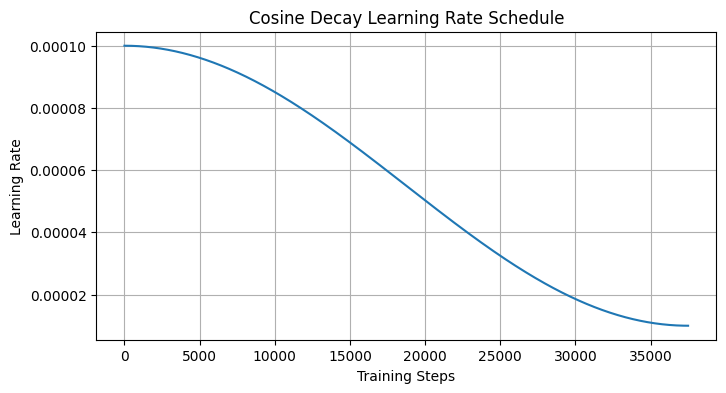

In [17]:
all_steps = np.arange(decay_steps)
lrs = [lr_schedule(step).numpy() for step in all_steps]

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8,4))
plt.plot(all_steps, lrs)
plt.title("Cosine Decay Learning Rate Schedule")
plt.xlabel("Training Steps")
plt.ylabel("Learning Rate")
plt.grid(True)
plt.show()

In [18]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])   
samples = np.array(list(train_counts))

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=np.concatenate([
        np.zeros(samples[0]),
        np.ones(samples[1])
    ])
)

class_weight_dict = {
    0: class_weights[0],
    1: class_weights[1]
}

print("Class Weights:", class_weight_dict)

Class Weights: {0: 0.9155214536570468, 1: 1.1016536518144235}


In [19]:
history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=EPOCH,
    callbacks=[restore_best],
    #class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/50


I0000 00:00:1765691517.928439      59 service.cc:148] XLA service 0x7e629c004230 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765691517.929355      59 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1765691547.751349      59 cuda_dnn.cc:529] Loaded cuDNN version 90300
E0000 00:00:1765691578.352497      59 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1765691578.536746      59 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1765691579.010273      59 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1765691579.2163

147/750 ━━━━━━━━━━━━━━━━━━━━ 6:22 634ms/step - accuracy: 0.6995 - auc: 0.7748 - loss: 0.7764 - precision: 0.6493 - recall: 0.7567

E0000 00:00:1765691841.469830      61 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1765691841.651858      61 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1765691842.094794      61 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1765691842.299564      61 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 871ms/step - accuracy: 0.7486 - auc: 0.8416 - loss: 0.7182 - precision: 0.6818 - recall: 0.8373
Model weights updated at epoch 1 with val_accuracy: 0.8686
750/750 ━━━━━━━━━━━━━━━━━━━━ 1091s 974ms/step - accuracy: 0.7486 - auc: 0.8417 - loss: 0.7181 - precision: 0.6819 - recall: 0.8373 - val_accuracy: 0.8686 - val_auc: 0.9474 - val_loss: 0.6231 - val_precision: 0.8265 - val_recall: 0.8993
Epoch 2/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 373s 496ms/step - accuracy: 0.8046 - auc: 0.9186 - loss: 0.6189 - precision: 0.7271 - recall: 0.9106 - val_accuracy: 0.8589 - val_auc: 0.9516 - val_loss: 0.5744 - val_precision: 0.7829 - val_recall: 0.9537
Epoch 3/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 373s 497ms/step - accuracy: 0.8317 - auc: 0.9354 - loss: 0.5699 - precision: 0.7566 - recall: 0.9268 - val_accuracy: 0.8649 - val_auc: 0.9559 - val_loss: 0.5224 - val_precision: 0.7980 - val_recall: 0.9405
Epoch 4/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step - accuracy: 0.8497 - auc: 0.948

In [20]:
model.save("Proposed_Model.keras") 

In [21]:
# Save history
with open('training_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

In [10]:
model = load_model('Proposed_Model.keras')  

In [11]:
# Load history
with open('training_history.pkl', 'rb') as f:
    history = pickle.load(f)

In [ ]:
epochs = range(1, len(history['loss']) + 1)

# Training and validation metrics
tr_loss = history['loss']
val_loss = history['val_loss']
tr_acc = history['accuracy']
val_acc = history['val_accuracy']
tr_precision = history['precision']
val_precision = history['val_precision']
tr_auc = history['auc']
val_auc = history['val_auc']

In [16]:
def print_best_metrics(metric_name, train, val):
    best_epoch = np.argmax(val) + 1
    print(f"📌 Best {metric_name} at epoch {best_epoch}:")
    print(f"   - Train {metric_name}: {abs(train[best_epoch - 1]):.4f}")
    print(f"   - Val {metric_name}:   {abs(val[best_epoch - 1]):.4f}\n")

print_best_metrics("Accuracy", tr_acc, val_acc)
print_best_metrics("Precision", tr_precision, val_precision)
print_best_metrics("AUC", tr_auc, val_auc)
print_best_metrics("Loss", [-x for x in tr_loss], [-x for x in val_loss])  # inverted for max-based search

📌 Best Accuracy at epoch 36:
   - Train Accuracy: 0.9782
   - Val Accuracy:   0.9373

📌 Best Precision at epoch 39:
   - Train Precision: 0.9717
   - Val Precision:   0.9801

📌 Best AUC at epoch 40:
   - Train AUC: 0.9991
   - Val AUC:   0.9844

📌 Best Loss at epoch 36:
   - Train Loss: 0.0141
   - Val Loss:   0.0448



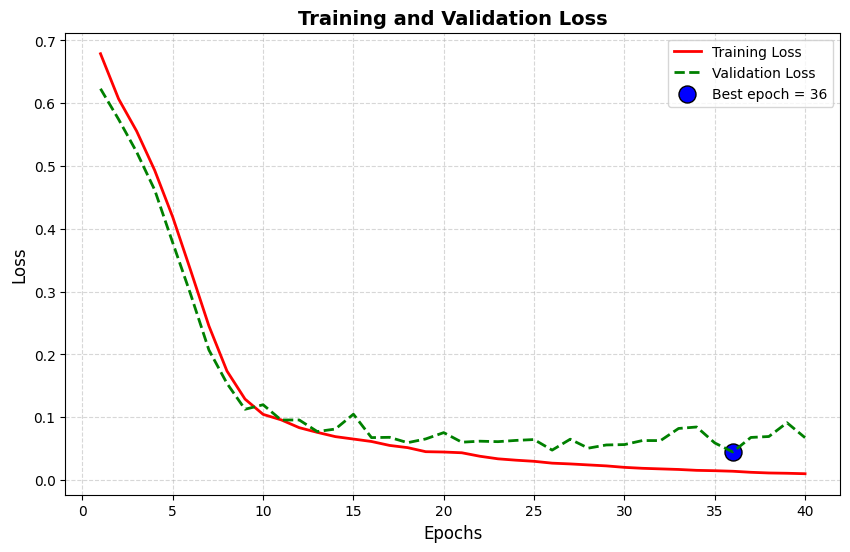

In [17]:
best_epoch_loss = np.argmin(val_loss)
best_val_loss = val_loss[best_epoch_loss]

plt.figure(figsize=(10, 6))
plt.plot(epochs, tr_loss, color='red', label='Training Loss', linewidth=2)
plt.plot(epochs, val_loss, color='green', label='Validation Loss', linestyle='--', linewidth=2)
plt.scatter(best_epoch_loss + 1, best_val_loss, s=150, c='blue',
            label=f'Best epoch = {best_epoch_loss + 1}', edgecolors='black')
plt.title('Training and Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=10)
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.show()

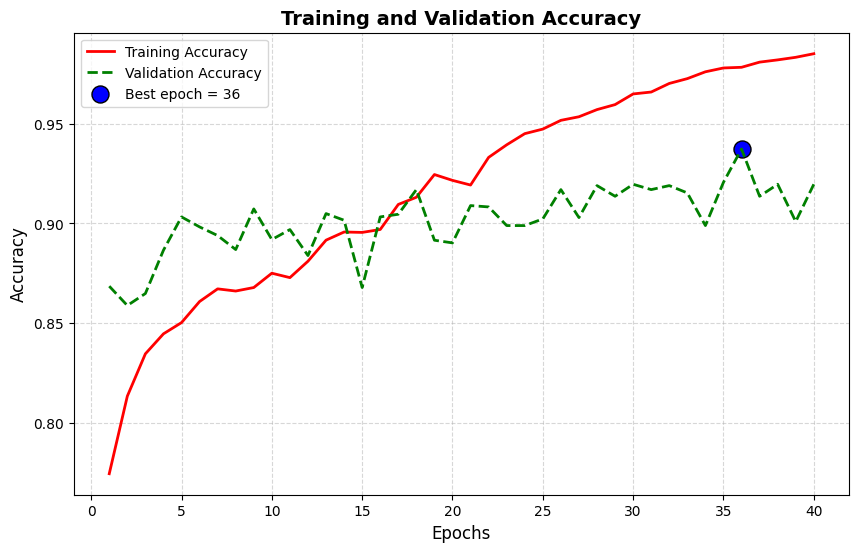

In [18]:
best_epoch_acc = np.argmax(val_acc)
best_val_acc = val_acc[best_epoch_acc]

plt.figure(figsize=(10, 6))
plt.plot(epochs, tr_acc, color='red', label='Training Accuracy', linewidth=2)
plt.plot(epochs, val_acc, color='green', label='Validation Accuracy', linestyle='--', linewidth=2)
plt.scatter(best_epoch_acc + 1, best_val_acc, s=150, c='blue',
            label=f'Best epoch = {best_epoch_acc + 1}', edgecolors='black')
plt.title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=10)
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.show()


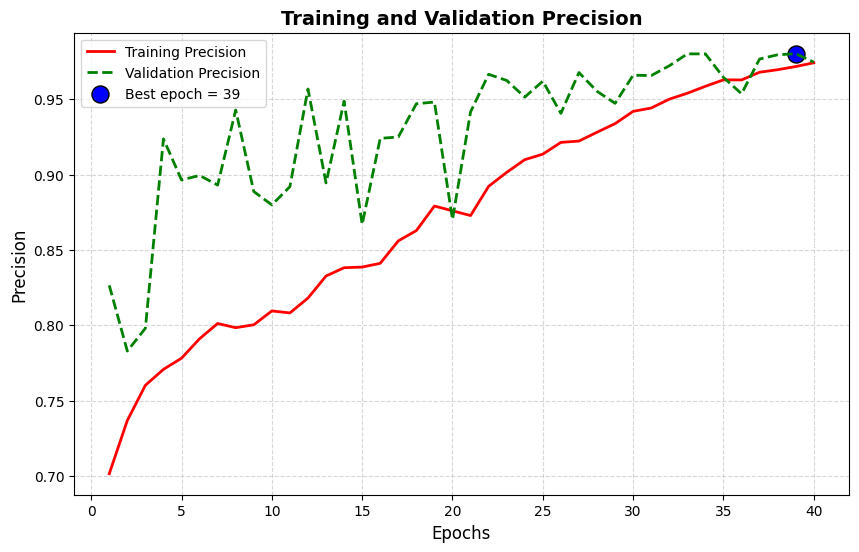

In [19]:
best_epoch_prec = np.argmax(val_precision)
best_val_prec = val_precision[best_epoch_prec]

plt.figure(figsize=(10, 6))
plt.plot(epochs, tr_precision, color='red', label='Training Precision', linewidth=2)
plt.plot(epochs, val_precision, color='green', label='Validation Precision', linestyle='--', linewidth=2)
plt.scatter(best_epoch_prec + 1, best_val_prec, s=150, c='blue',
            label=f'Best epoch = {best_epoch_prec + 1}', edgecolors='black')
plt.title('Training and Validation Precision', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.legend(fontsize=10)
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.show()


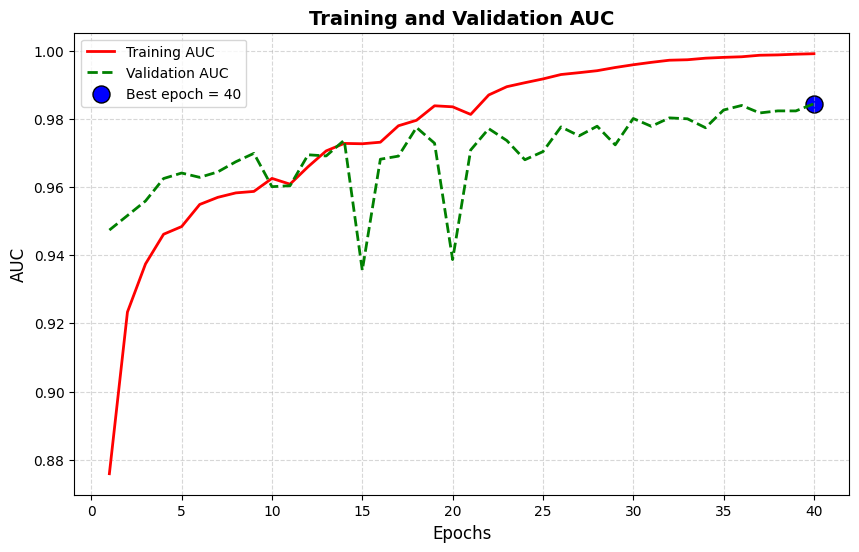

In [20]:
best_epoch_auc = np.argmax(val_auc)
best_val_auc = val_auc[best_epoch_auc]

plt.figure(figsize=(10, 6))
plt.plot(epochs, tr_auc, color='red', label='Training AUC', linewidth=2)
plt.plot(epochs, val_auc, color='green', label='Validation AUC', linestyle='--', linewidth=2)
plt.scatter(best_epoch_auc + 1, best_val_auc, s=150, c='blue',
            label=f'Best epoch = {best_epoch_auc + 1}', edgecolors='black')
plt.title('Training and Validation AUC', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('AUC', fontsize=12)
plt.legend(fontsize=10)
plt.grid(visible=True, linestyle='--', alpha=0.5)
plt.show()


Evaluating: SkinCancerModel
Total steps: 94


Evaluating SkinCancerModel: 100%|██████████| 94/94 [01:40<00:00,  1.06s/it]



Total samples evaluated: 2998
Class distribution: [1638 1360]

PERFORMANCE METRICS
Accuracy  : 0.9446
Precision : 0.9671
Recall    : 0.9088
F1 Score  : 0.9371
AUC       : 0.9868

Classification Report:

              precision    recall  f1-score   support

      Benign       0.93      0.97      0.95      1638
    Melanoma       0.97      0.91      0.94      1360

    accuracy                           0.94      2998
   macro avg       0.95      0.94      0.94      2998
weighted avg       0.95      0.94      0.94      2998



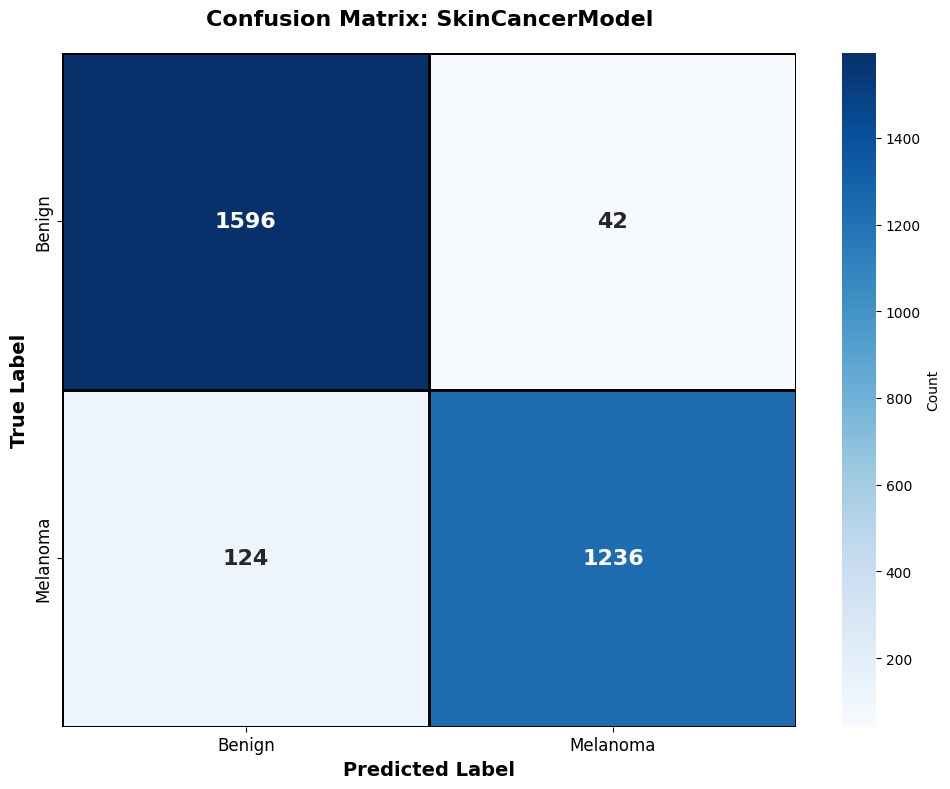

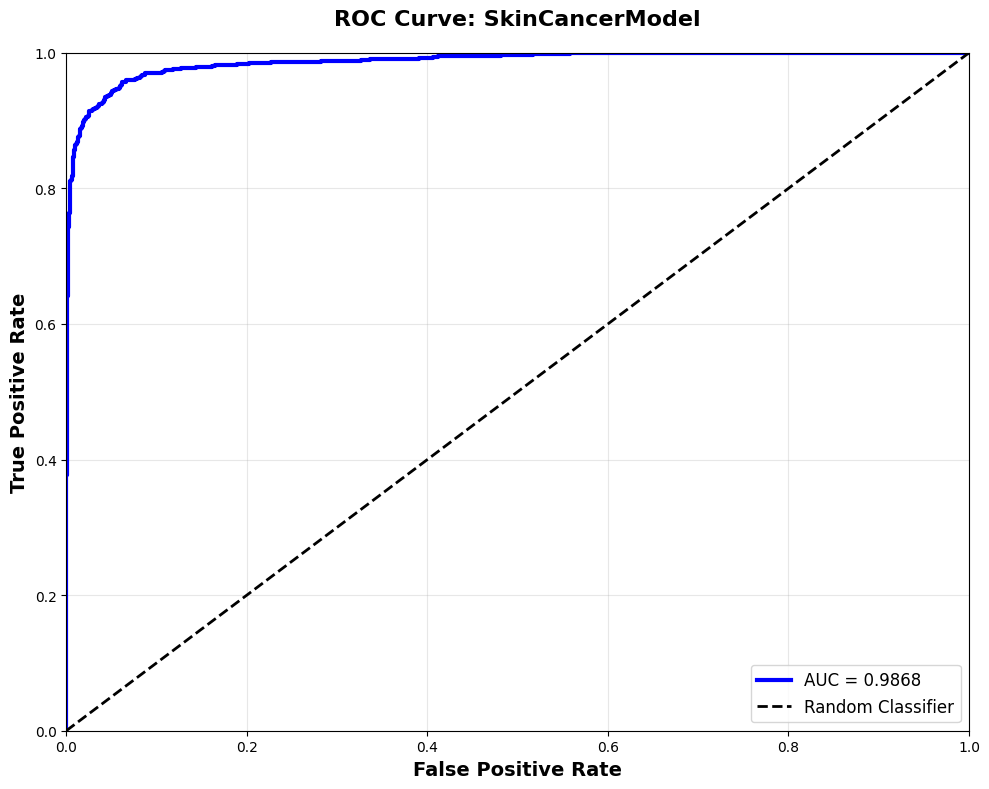


Test Accuracy: 0.9446
Test AUC: 0.9868


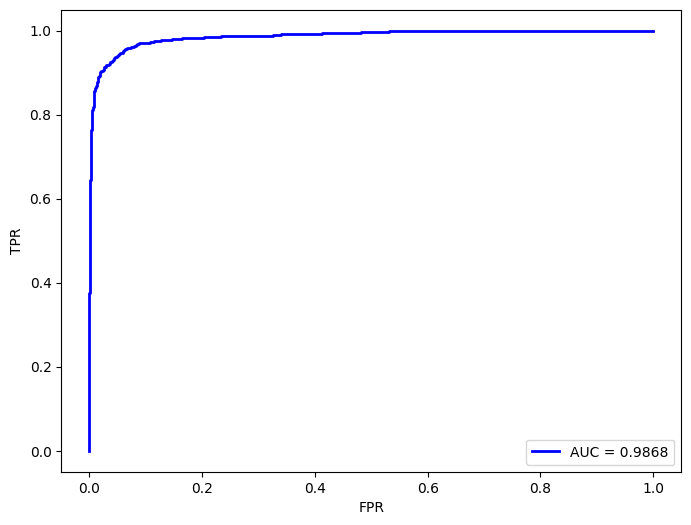

In [30]:

# ==========================================
# Model Evaluation Function
# ==========================================
def evaluate_model(model, test_generator, labels, model_name, batch_size=32):
    """
    Evaluate a trained binary-classification model with dual inputs (image + handcrafted features).

    Args:
        model: Trained Keras model expecting ((img, hf), labels)
        test_generator: HandcraftedGeneratorWrapper instance
        labels: List of class names (e.g., ['Benign', 'Melanoma'])
        model_name: Name for display
        batch_size: Batch size (used for step calculation)

    Returns:
        metrics_dict: Dictionary with all metrics
        auc_curve_data: FPR, TPR for ROC curve plotting
    """

    steps = len(test_generator)

    y_true = []
    y_pred = []
    y_probs = []

    print(f"\n{'='*80}")
    print(f"Evaluating: {model_name}")
    print(f"{'='*80}")
    print(f"Total steps: {steps}")

    # Loop through test generator
    for step_idx in tqdm(range(steps), desc=f"Evaluating {model_name}", total=steps):
        # Get batch from generator
        images, labels_batch = test_generator[step_idx]

        # Predict using both inputs
        preds = model.predict(
            images,
            verbose=0
        )  # sigmoid outputs (probability of class 1)

        preds = preds.reshape(-1)

        y_probs.extend(preds)                      # probability for class 1
        y_pred.extend((preds >= 0.5).astype(int))  # binary classification using threshold 0.5

        # Labels from generator (binary)
        labels_batch = labels_batch.reshape(-1)
        y_true.extend(labels_batch.astype(int))

    # Convert to arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_probs = np.array(y_probs)

    print(f"\nTotal samples evaluated: {len(y_true)}")
    print(f"Class distribution: {np.bincount(y_true)}")

    # Metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    try:
        auc = roc_auc_score(y_true, y_probs)
    except ValueError:
        auc = float("nan")

    # Classification report
    report = classification_report(y_true, y_pred, target_names=labels, zero_division=0)

    # Print metrics
    print(f"\n{'='*80}")
    print(f"PERFORMANCE METRICS")
    print(f"{'='*80}")
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"AUC       : {auc:.4f}")
    print(f"{'='*80}\n")

    print("Classification Report:\n")
    print(report)

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        linewidths=2,
        linecolor='black',
        xticklabels=labels,
        yticklabels=labels,
        annot_kws={"size": 16, "weight": "bold"},
        cbar_kws={"label": "Count"}
    )

    plt.title(f'Confusion Matrix: {model_name}', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Predicted Label', fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=14, fontweight='bold')
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_probs)

    plt.figure(figsize=(10, 8))
    plt.plot(fpr, tpr, 'b-', linewidth=3, label=f'AUC = {auc:.4f}')
    plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')
    plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold')
    plt.ylabel('True Positive Rate', fontsize=14, fontweight='bold')
    plt.title(f'ROC Curve: {model_name}', fontsize=16, fontweight='bold', pad=20)
    plt.legend(fontsize=12, loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.tight_layout()
    plt.show()

    auc_curve_data = {"fpr": fpr, "tpr": tpr, "auc": auc}

    return {
        "model_name": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "auc": auc,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_probs": y_probs,
        "confusion_matrix": cm
    }, auc_curve_data


# Evaluate
metrics, roc_data = evaluate_model(
    model=model,
    test_generator=test_data,
    labels=['Benign', 'Melanoma'],
    model_name='SkinCancerModel',
    batch_size=32
)

# Access results
print(f"\nTest Accuracy: {metrics['accuracy']:.4f}")
print(f"Test AUC: {metrics['auc']:.4f}")

# Plot ROC curve
fpr, tpr, auc = roc_data['fpr'], roc_data['tpr'], roc_data['auc']
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {auc:.4f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.show()


----------------
Bootstrap 95% Confidence interval


In [31]:
# -----------------------------
# Parameters
# -----------------------------
B = 1000                # number of bootstrap samples
RNG_SEED = 42

# 1) Get predictions and true labels
probs = model.predict(test_data, verbose=1).ravel()   # shape (N,) after ravel for binary
y_true = np.asarray(test_data.classes)                # shape (N,)
y_pred = (probs >= 0.5).astype(int)                   # thresholding for binary

# Point estimates
point_accuracy = accuracy_score(y_true, y_pred)
point_precision = precision_score(y_true, y_pred, average='binary', zero_division=0)
point_recall = recall_score(y_true, y_pred, average='binary', zero_division=0)
point_f1 = f1_score(y_true, y_pred, average='binary', zero_division=0)

# AUC for binary
try:
    point_auc = roc_auc_score(y_true, probs)
except Exception:
    point_auc = np.nan

94/94 ━━━━━━━━━━━━━━━━━━━━ 66s 444ms/step


In [32]:
# 2) Bootstrap
rng = np.random.RandomState(RNG_SEED)
metrics_boot = {k: [] for k in ["accuracy", "precision", "recall", "f1", "auc"]}
N = len(y_true)

for i in tqdm(range(B), desc="Bootstrap samples"):
    idx = rng.randint(0, N, size=N)   # sample with replacement
    y_true_b, y_pred_b, probs_b = y_true[idx], y_pred[idx], probs[idx]

    metrics_boot["accuracy"].append(accuracy_score(y_true_b, y_pred_b))
    metrics_boot["precision"].append(precision_score(y_true_b, y_pred_b, average='macro', zero_division=0))
    metrics_boot["recall"].append(recall_score(y_true_b, y_pred_b, average='macro', zero_division=0))
    metrics_boot["f1"].append(f1_score(y_true_b, y_pred_b, average='macro', zero_division=0))

    #probs_b = probs_b.ravel()   # ensure shape (N,)
    
    try:
        auc_b = roc_auc_score(y_true_b, probs_b)
    except Exception:
        auc_b = np.nan
    
    metrics_boot["auc"].append(auc_b)


# Convert lists to arrays
for k in metrics_boot:
    metrics_boot[k] = np.array(metrics_boot[k], dtype=np.float32)

Bootstrap samples: 100%|██████████| 1000/1000 [00:05<00:00, 180.22it/s]


In [33]:
# 3) Compute 95% CI
def ci95(arr):
    arr = arr[~np.isnan(arr)]
    if len(arr) == 0:
        return (np.nan, np.nan)
    return np.percentile(arr, [2.5, 97.5])

results = []
for name, point in [
    ("accuracy", point_accuracy),
    ("precision", point_precision),
    ("recall", point_recall),
    ("f1", point_f1),
    ("auc", point_auc)
]:
    lo, hi = ci95(metrics_boot[name])
    results.append({
        "metric": name,
        "point_estimate": point,
        "ci_lower": lo,
        "ci_upper": hi,
        "n_boot_valid": int(np.sum(~np.isnan(metrics_boot[name])))
    })

df_results = pd.DataFrame(results).set_index("metric")
pd.set_option("display.float_format", "{:.4f}".format)
print(df_results)

           point_estimate  ci_lower  ci_upper  n_boot_valid
metric                                                     
accuracy           0.9446    0.9366    0.9530          1000
precision          0.9671    0.9397    0.9555          1000
recall             0.9088    0.9330    0.9503          1000
f1                 0.9371    0.9355    0.9523          1000
auc                0.9868    0.9831    0.9900          1000


In [34]:
def plot_bootstrap_metrics(metrics_boot, df_results, n_cols=3, figsize_per_plot=(5, 4),
                           w_pad=0.6, h_pad=1.5, shift_factor=0.5):
    """
    Plot bootstrap metric distributions.

    Args:
        metrics_boot: dict of metric -> bootstrap array
        df_results: DataFrame with point estimates and CIs
        n_cols: 
            >0 -> number of columns for grid layout
             0 -> plot each metric separately (one figure per metric)
        figsize_per_plot: (width, height) per subplot
        w_pad: horizontal gap between subplots (grid mode only)
        h_pad: vertical gap between subplots (grid mode only)
        shift_factor: how much to center last row if not full (grid mode only)
    """

    metrics = list(metrics_boot.keys())
    n_metrics = len(metrics)

    # --------------------
    # Single-plot mode
    # --------------------
    if n_cols == 0:
        for metric in metrics:
            vals = metrics_boot[metric]
            vals_nonan = vals[~np.isnan(vals)]

            fig, ax = plt.subplots(figsize=figsize_per_plot)
            ax.hist(vals_nonan, bins=40, alpha=0.8, color="skyblue", edgecolor="k")
            ax.axvline(np.nanpercentile(vals_nonan, 50), color='k', linestyle='--', label='median')
            ax.axvline(df_results.loc[metric, "ci_lower"], color='r', linestyle='-')
            ax.axvline(df_results.loc[metric, "ci_upper"], color='r', linestyle='-', label='95% CI')

            ax.set_title(f"{metric}\npt={df_results.loc[metric,'point_estimate']:.3f}")
            ax.legend()
            plt.tight_layout()
            plt.show()
        return  # done

    # --------------------
    # Grid mode
    # --------------------
    n_rows = int(np.ceil(n_metrics / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(figsize_per_plot[0]*n_cols,
                                      figsize_per_plot[1]*n_rows))
    axes = np.array(axes).reshape(-1)  # flatten

    for i, metric in enumerate(metrics):
        ax = axes[i]
        vals = metrics_boot[metric]
        vals_nonan = vals[~np.isnan(vals)]

        ax.hist(vals_nonan, bins=40, alpha=0.8, color="skyblue", edgecolor="k")
        ax.axvline(np.nanpercentile(vals_nonan, 50), color='k', linestyle='--', label='median')
        ax.axvline(df_results.loc[metric, "ci_lower"], color='r', linestyle='-')
        ax.axvline(df_results.loc[metric, "ci_upper"], color='r', linestyle='-', label='95% CI')

        ax.set_title(f"{metric}\npt={df_results.loc[metric,'point_estimate']:.3f}")
        ax.legend()

        # 🔹 Format x-axis ticks to 2 decimal places
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.2f}"))

    # remove unused axes
    for j in range(n_metrics, len(axes)):
        fig.delaxes(axes[j])

    # ---- Center last row if it's not full ----
    last_row_count = n_metrics % n_cols
    if last_row_count != 0:
        empty_slots = n_cols - last_row_count
        last_row_axes = axes[n_cols*(n_rows-1):n_cols*(n_rows-1)+last_row_count]

        for ax in last_row_axes:
            pos = ax.get_position()
            shift = (empty_slots / n_cols) * shift_factor
            pos_new = [pos.x0 + shift, pos.y0, pos.width, pos.height]
            ax.set_position(pos_new)

    plt.tight_layout(pad=1.0, w_pad=w_pad, h_pad=h_pad)
    plt.show()

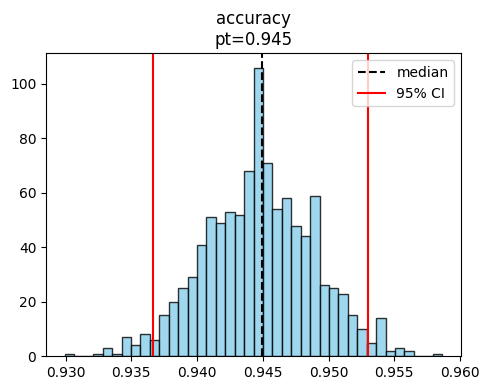

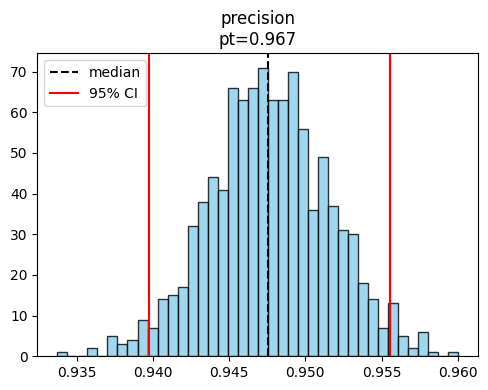

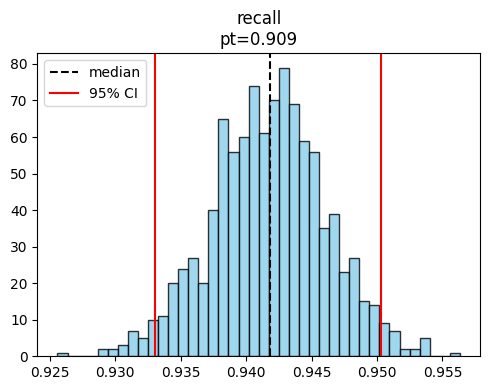

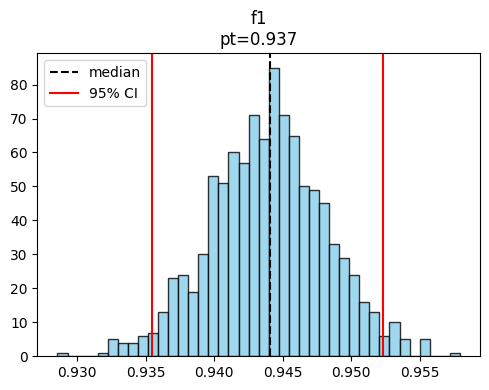

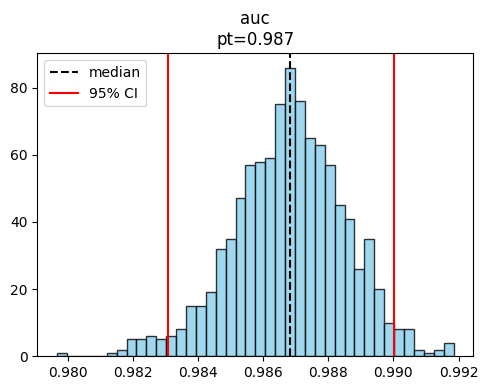

In [35]:
plot_bootstrap_metrics(
    metrics_boot, 
    df_results, 
    n_cols=0,        # number of columns in grid (set 0 for separate plots, 2 or 3 for grid)
    w_pad=0.5,       # horizontal space between columns (increase -> wider gap)
    h_pad=1.0,       # vertical space between rows (increase -> taller gap)
    shift_factor=0.0 # how much to horizontally shift last-row plots for centering
)


--------------------
Gradcam ++ (more advance visualization than previous version of mine)

In [21]:
# ================= Grad-CAM++ Class =================
class GradCAMPlusPlus:
    def __init__(self, model, target_layer, labels):
        self.model = model
        self.labels = labels
        try:
            self.target_layer = model.get_layer(target_layer)
        except:
            print(f"❌ Layer '{target_layer}' not found!")
            print(f"Available Conv layers: {[l.name for l in model.layers if 'Conv' in l.__class__.__name__]}")
            raise
        print(f"✓ Grad-CAM++ initialized with layer: {target_layer}")

    def compute_gradcam_plus_plus(self, image, class_idx):
        img_tensor = tf.expand_dims(tf.convert_to_tensor(image, dtype=tf.float32), 0)
        intermediate_model = Model(inputs=self.model.input, outputs=[self.target_layer.output, self.model.output])
        with tf.GradientTape() as tape:
            layer_output, predictions = intermediate_model(img_tensor)
            tape.watch(layer_output)
            loss = predictions[0, class_idx]
        gradients = tape.gradient(loss, layer_output)
        layer_output_np = layer_output.numpy()[0]
        gradients_np = gradients.numpy()[0]
        second_deriv = np.power(gradients_np, 2)
        third_deriv = second_deriv * gradients_np
        alpha_denom = 2 * second_deriv + np.sum(third_deriv * layer_output_np, axis=(0, 1), keepdims=True)
        alpha_denom = np.where(alpha_denom != 0, alpha_denom, 1e-8)
        alpha = second_deriv / alpha_denom
        alpha = np.maximum(alpha, 0)
        weights = np.sum(alpha * np.maximum(gradients_np, 0), axis=(0, 1))
        weights = weights / (np.sum(weights) + 1e-8)
        cam = np.zeros(layer_output_np.shape[:2])
        for i, w in enumerate(weights):
            cam += w * layer_output_np[:, :, i]
        cam = np.maximum(cam, 0)
        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

    def predict_and_explain(self, image):
        img_tensor = tf.expand_dims(tf.convert_to_tensor(image, dtype=tf.float32), 0)
        preds = self.model.predict(img_tensor, verbose=0)[0]
        pred_idx = int(np.argmax(preds))
        confidence = float(preds[pred_idx])
        gradcam = self.compute_gradcam_plus_plus(image, pred_idx)
        gradcam_resized = tf.image.resize(tf.expand_dims(gradcam, -1), image.shape[:2]).numpy()[..., 0]
        return {'prediction': self.labels[pred_idx], 'confidence': confidence, 'gradcam': gradcam_resized, 'preds': preds}

    def visualize_gradcam_plus_plus(self, image, figsize=(14, 4)):
        result = self.predict_and_explain(image)
        fig, axes = plt.subplots(1, 3, figsize=figsize)
        fig.suptitle(f'Grad-CAM++: {result["prediction"]} ({result["confidence"]:.1%})', fontsize=14, fontweight='bold')
        # Original image
        axes[0].imshow(np.clip(image*255,0,255).astype(np.uint8)); axes[0].set_title('Original'); axes[0].axis('off')
        # Heatmap overlay
        axes[1].imshow(np.clip(image*255,0,255).astype(np.uint8), alpha=1.0)
        im = axes[1].imshow(result['gradcam'], cmap='jet', alpha=0.5)
        axes[1].set_title('Grad-CAM++ Heatmap'); axes[1].axis('off'); plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
        # Blended overlay
        img_norm = image/255.0 if image.max()>1 else image
        heatmap_rgb = plt.cm.jet(result['gradcam'])[..., :3]
        alpha_blend = result['gradcam'][..., np.newaxis]
        overlay = (1-alpha_blend)*img_norm + alpha_blend*heatmap_rgb
        overlay = np.clip(overlay, 0, 1)
        axes[2].imshow(overlay); axes[2].set_title('Blended Overlay'); axes[2].axis('off')
        plt.tight_layout()
        return fig

(224, 224, 3)
✓ Grad-CAM++ initialized with layer: fusion_conv


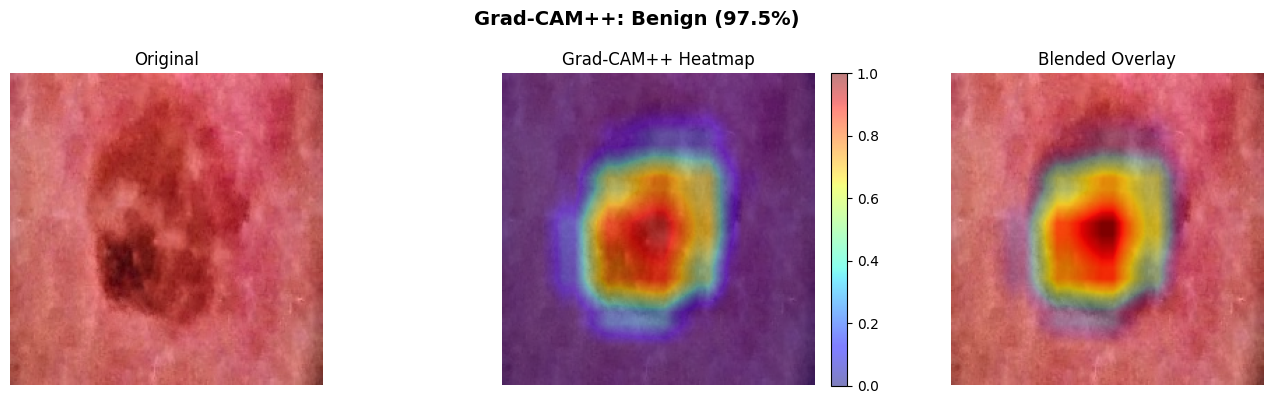

In [54]:
# ================= Example Usage =================
target_layer = 'fusion_conv'    #'conv2d_72'  
image = test_data[0][0][24]
print(image.shape)
explainer = GradCAMPlusPlus(model, target_layer, labels)
fig = explainer.visualize_gradcam_plus_plus(image)
plt.show()

In [23]:
# ================= Score-CAM Class =================
class ScoreCAM:
    def __init__(self, model, target_layer, labels, max_channels=32):
        self.model = model
        self.labels = labels
        self.max_channels = max_channels
        try:
            self.target_layer = model.get_layer(target_layer)
        except:
            print(f"❌ Layer '{target_layer}' not found!")
            print(f"Available Conv layers: {[l.name for l in model.layers if 'Conv' in l.__class__.__name__]}")
            raise
        print(f"✓ Score-CAM initialized with layer: {target_layer}")

    def compute_scorecam(self, image, class_idx):
        img_tensor = tf.expand_dims(tf.convert_to_tensor(image, dtype=tf.float32), 0)

        # Model for feature maps
        feature_model = Model(self.model.input, self.target_layer.output)
        feature_maps = feature_model(img_tensor)[0]  # (H, W, C)

        num_channels = min(feature_maps.shape[-1], self.max_channels)
        cam = np.zeros(feature_maps.shape[:2], dtype=np.float32)

        for i in range(num_channels):
            fmap = feature_maps[..., i]

            # Normalize activation map
            fmap = np.maximum(fmap, 0)
            if fmap.max() == 0:
                continue
            fmap_norm = fmap / (fmap.max() + 1e-8)

            # Resize to input size
            fmap_resized = tf.image.resize(
                fmap_norm[..., np.newaxis], image.shape[:2]
            ).numpy()

            # Mask input image
            masked_img = image * fmap_resized

            # Get class score
            masked_tensor = tf.expand_dims(masked_img, 0)
            score = self.model(masked_tensor, training=False)[0, class_idx]

            cam += score.numpy() * fmap_norm

        cam = np.maximum(cam, 0)
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

    def predict_and_explain(self, image):
        img_tensor = tf.expand_dims(tf.convert_to_tensor(image, dtype=tf.float32), 0)
        preds = self.model.predict(img_tensor, verbose=0)[0]
        pred_idx = int(np.argmax(preds))
        confidence = float(preds[pred_idx])

        scorecam = self.compute_scorecam(image, pred_idx)
        scorecam_resized = tf.image.resize(
            scorecam[..., np.newaxis], image.shape[:2]
        ).numpy()[..., 0]

        return {
            'prediction': self.labels[pred_idx],
            'confidence': confidence,
            'scorecam': scorecam_resized,
            'preds': preds
        }

    def visualize_scorecam(self, image, figsize=(14, 4)):
        result = self.predict_and_explain(image)

        fig, axes = plt.subplots(1, 3, figsize=figsize)
        fig.suptitle(
            f'Score-CAM: {result["prediction"]} ({result["confidence"]:.1%})',
            fontsize=14, fontweight='bold'
        )

        # Original image
        axes[0].imshow(np.clip(image*255,0,255).astype(np.uint8))
        axes[0].set_title('Original')
        axes[0].axis('off')

        # Heatmap overlay
        axes[1].imshow(np.clip(image*255,0,255).astype(np.uint8))
        im = axes[1].imshow(result['scorecam'], cmap='jet', alpha=0.5)
        axes[1].set_title('Score-CAM Heatmap')
        axes[1].axis('off')
        plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

        # Blended overlay
        img_norm = image/255.0 if image.max()>1 else image
        heatmap_rgb = plt.cm.jet(result['scorecam'])[..., :3]
        alpha = result['scorecam'][..., np.newaxis]
        overlay = (1-alpha)*img_norm + alpha*heatmap_rgb
        overlay = np.clip(overlay, 0, 1)

        axes[2].imshow(overlay)
        axes[2].set_title('Blended Overlay')
        axes[2].axis('off')

        plt.tight_layout()
        return fig


✓ Score-CAM initialized with layer: fusion_conv


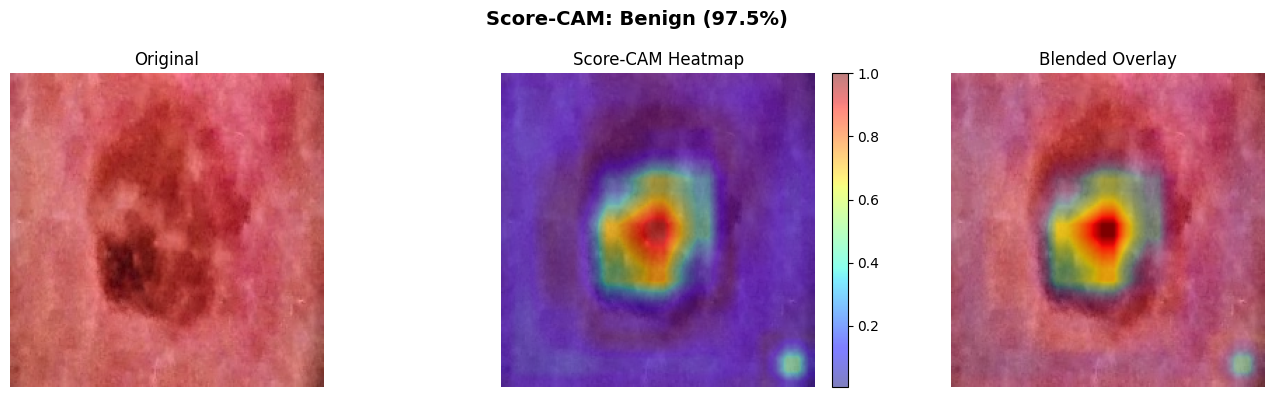

In [55]:
target_layer = 'fusion_conv'
image = test_data[0][0][24]

explainer = ScoreCAM(model, target_layer, labels)
fig = explainer.visualize_scorecam(image)
plt.show()